# 04 — Optimal Experimental Design

Simulate the full (circuit × dosage) grid and identify which experiments carry the most information — measured by prediction variance across the belief ensemble.

The heatmap shows information scores; red boxes mark the selected budget experiments.

In [1]:
import os
# Navigate to repo root so all relative paths resolve correctly.
if os.path.basename(os.getcwd()) in ('notebooks', 'examples'):
    os.chdir('..')

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from gcad.circuit import Topo  # required for pickle deserialization
from active_learning.config import ActiveLearningConfig
from active_learning.designer import ExperimentDesigner

# Load circuits
with open(os.path.join("data", "selected_M_circuits.pkl"), "rb") as f:
    circuits_list = pickle.load(f)
circuit_dict = {f"Circuit_{i+1}": c for i, c in enumerate(circuits_list)}

# Load prior ensemble
with open("workspace/prior_belief_cloud_N200_spread2.0.pkl", "rb") as f:
    belief_cloud = pickle.load(f)

# Load promoter parameters
with open(os.path.join("gcad", "data", "promo.pkl"), "rb") as f:
    promo_params = pickle.load(f)

print(f"Loaded {len(circuit_dict)} circuits and {len(belief_cloud)} prior models.")

Loaded 3 circuits and 200 prior models.


## Configure Designer

In [3]:
config = ActiveLearningConfig(
    dosages=list(np.round(np.arange(0.2, 4.2, 0.2), 2)),
    budget_circuits=2,
    budget_dosages=2
)

designer = ExperimentDesigner(circuit_dict, config)
print(f"Dosage candidates: {len(config.dosages)} | Budget: {config.budget_circuits} circuits x {config.budget_dosages} dosages")

Dosage candidates: 20 | Budget: 2 circuits x 2 dosages


## Run Experimental Design

In [4]:
selected_experiments, variance_matrix, all_simulations = designer.design_experiment(belief_cloud, promo_params)

print("\nSelected experiments:")
for c_name, dose in selected_experiments:
    print(f"  {c_name} at {dose:.2f}x dosage")

[Designer] Simulating Grid: 100%|██████████| 60/60 [04:58<00:00,  4.98s/exp]


Selected experiments:
  Circuit_3 at 2.00x dosage
  Circuit_3 at 2.20x dosage
  Circuit_1 at 2.40x dosage
  Circuit_1 at 3.00x dosage


## Heatmap — Information Score by (Circuit, Dosage)

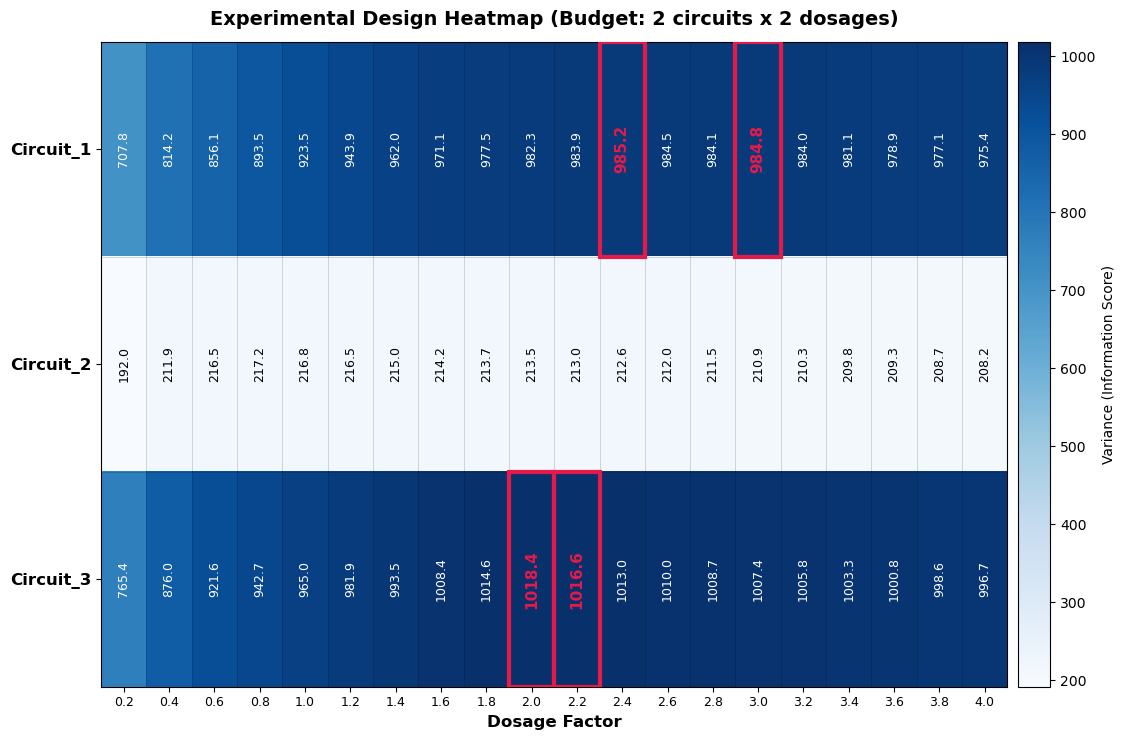

In [5]:
# Reconstruct selected (circuit, dosage) indices for highlighting
circuit_names = list(circuit_dict.keys())
dosages = config.dosages
selected_indices = set()
for c_name, dose in selected_experiments:
    c_idx = circuit_names.index(c_name)
    d_idx = min(range(len(dosages)), key=lambda i: abs(dosages[i] - dose))
    selected_indices.add((c_idx, d_idx))

fig, ax = plt.subplots(figsize=(12, max(4, len(circuit_dict) * 2.5)))
cax = ax.imshow(variance_matrix, aspect='auto', cmap='Blues')
fig.colorbar(cax, label='Variance (Information Score)', pad=0.01)

ax.set_yticks(np.arange(len(circuit_dict)))
ax.set_yticklabels(circuit_names, fontweight='bold', fontsize=12)
ax.set_xticks(np.arange(len(dosages)))
ax.set_xticklabels([f"{d:.1f}" for d in dosages], rotation=0, fontsize=9)
ax.set_xlabel('Dosage Factor', fontweight='bold', fontsize=12)
ax.set_title(f'Experimental Design Heatmap (Budget: {config.budget_circuits} circuits x {config.budget_dosages} dosages)',
             fontweight='bold', fontsize=14, pad=12)

max_var = max(np.max(variance_matrix), 1e-12)
for i in range(variance_matrix.shape[0]):
    for j in range(variance_matrix.shape[1]):
        val = variance_matrix[i, j]
        is_sel = (i, j) in selected_indices
        if is_sel:
            rect = Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='#e6194B', lw=3, zorder=3)
            ax.add_patch(rect)
            ax.text(j, i, f"{val:.1f}", color='#e6194B', ha='center', va='center',
                    fontweight='heavy', fontsize=11, rotation=90, zorder=4)
        else:
            text_color = 'white' if (val / max_var) > 0.6 else 'black'
            ax.text(j, i, f"{val:.1f}", color=text_color, ha='center', va='center',
                    fontsize=9, rotation=90, zorder=4)

ax.set_xticks(np.arange(-0.5, len(dosages), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(circuit_dict), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5, alpha=0.2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()

## Save Decisions

In [6]:
os.makedirs("workspace", exist_ok=True)
output = {
    'selected_experiments': selected_experiments,
    'variance_matrix': variance_matrix,
    'candidate_dosages': dosages,
    'selected_indices': list(selected_indices)
}
with open("workspace/designer_decisions_cycle_0.pkl", 'wb') as f:
    pickle.dump(output, f)
print("Saved designer decisions to 'workspace/designer_decisions_cycle_0.pkl'.")

Saved designer decisions to 'workspace/designer_decisions_cycle_0.pkl'.
